# Decision Tree Worksheet

In [6]:
import numpy as np
import pandas as po
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [8]:
path = 'diabetes.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = po.read_csv(path, names = names)
## YOUR CODE HERE
invalid = ['plas', 'pres', 'skin', 'test', 'mass']
for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace = True)
data = data.dropna(axis=0).reset_index(drop=True)

X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col],test_size = test_size, random_state = 0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

/var/folders/g8/knwm1vbj1szdqspplz1tls4m0000gn/T/ipykernel_83004/3527480716.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace = True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [0]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state=None,
                                        max_depth = 50, min_samples_leaf = 5)
decision_tree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Print accuracy of training and validation data.

In [11]:
## YOUR CODE HERE
y_train_pred = decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train,y_train_pred)*100)
y_val_pred = decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  92.0
Validation Accuracy is  71.42857142857143


Make a model with a low max-depth and higher minimum sample leafs.

In [15]:
## YOUR CODE HERE
decision_tree_1= DecisionTreeClassifier(criterion = "entropy", random_state=None,
                                       max_depth = 5, min_samples_leaf=50)
decision_tree_1.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Print accuracy of training and validation data.

In [16]:
## YOUR CODE HERE
y_train_pred = decision_tree_1.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred = decision_tree_1.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred)*100)

Training Accuracy is  77.2
Validation Accuracy is  73.01587301587301


Explain the accuracy results below. 

The validation accuracy was higher than the traning accuracy when we used a low max-depth and a higher minimum sample leafs. However, when we used a high max-depth and a small minimum sample, the training accuracy was higher than the validation accuracy. 

## Metrics

Use graphviz to visualize your 2nd tree.

In [18]:
!pip install graphviz

In [20]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(decision_tree_1, out_file = None, filled=True)
graph = graphviz.Source(dot_data)
print(graph)

digraph Tree {
node [shape=box, style="filled", color="black", fontname="helvetica"] ;
edge [fontname="helvetica"] ;
0 [label="x[1] <= 127.5\nentropy = 0.913\nsamples = 250\nvalue = [168, 82]", fillcolor="#f2be9a"] ;
1 [label="x[6] <= 0.627\nentropy = 0.589\nsamples = 155\nvalue = [133, 22]", fillcolor="#e9965a"] ;
0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;
2 [label="x[6] <= 0.306\nentropy = 0.353\nsamples = 105\nvalue = [98, 7]", fillcolor="#e78a47"] ;
1 -> 2 ;
3 [label="entropy = 0.469\nsamples = 50\nvalue = [45, 5]", fillcolor="#e88f4f"] ;
2 -> 3 ;
4 [label="entropy = 0.225\nsamples = 55\nvalue = [53, 2]", fillcolor="#e68640"] ;
2 -> 4 ;
5 [label="entropy = 0.881\nsamples = 50\nvalue = [35, 15]", fillcolor="#f0b78e"] ;
1 -> 5 ;
6 [label="entropy = 0.949\nsamples = 95\nvalue = [35, 60]", fillcolor="#acd6f4"] ;
0 -> 6 [labeldistance=2.5, labelangle=-45, headlabel="False"] ;
}



#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

THe value of a feature n in given observation.

Question 2: What is the root feature? Does it make sense as the root feature?

The root feature is x[0] which corresponds to "preg". This stands for the number of times preganent. It kind of does not make sense to be the root feature since I wouldn't think thats the biggest predictor of diabetes and we want to look for one that can split the most data early on.

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

The training accuracy will be 100% since the tree will keep splitting until it understands the data and ultimately memorizes it. Becuase of the overfit however, the testing accuracy will be much much lower since the datast might not be a accurate representation of the population sample.

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [21]:
## YOUR CODE HERE
decision_tree_1= DecisionTreeClassifier(criterion = "entropy", random_state=None,
                                       max_depth = 500, min_samples_leaf=1)
decision_tree_1.fit(X_train, y_train)
y_train_pred = decision_tree_1.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred = decision_tree_1.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  79.36507936507937


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [22]:
## YOUR CODE HERE
random_forest = RandomForestClassifier(n_estimators = 100)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Print accuracy of training and validation data.

In [24]:
## YOUR CODE HERE
y_train_pred=random_forest.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=random_forest.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  82.53968253968253


How did the accuracy compare to the decision tree's accuracy?

The traning accuracy was 100 but the validation accuracy was higher than the decision tree's accuracy.

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [26]:
## YOUR CODE HERE
importance = random_forest.feature_importances_
indices = np.argsort(importance)[::-1][:3]

for i in indices:
    print(X_cols[i], importance[i])


plas 0.27165311286888855
test 0.14492581609635055
age 0.1257549693585105


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

Trees: 1, Accuracy: 0.7302
Trees: 6, Accuracy: 0.7143
Trees: 11, Accuracy: 0.8095
Trees: 16, Accuracy: 0.7778
Trees: 21, Accuracy: 0.7937
Trees: 26, Accuracy: 0.8413
Trees: 31, Accuracy: 0.8413
Trees: 36, Accuracy: 0.8413
Trees: 41, Accuracy: 0.8413
Trees: 46, Accuracy: 0.8254
Trees: 51, Accuracy: 0.8413
Trees: 56, Accuracy: 0.8254
Trees: 61, Accuracy: 0.8571
Trees: 66, Accuracy: 0.8254
Trees: 71, Accuracy: 0.8095
Trees: 76, Accuracy: 0.8571
Trees: 81, Accuracy: 0.8571
Trees: 86, Accuracy: 0.8095
Trees: 91, Accuracy: 0.7937
Trees: 96, Accuracy: 0.7778


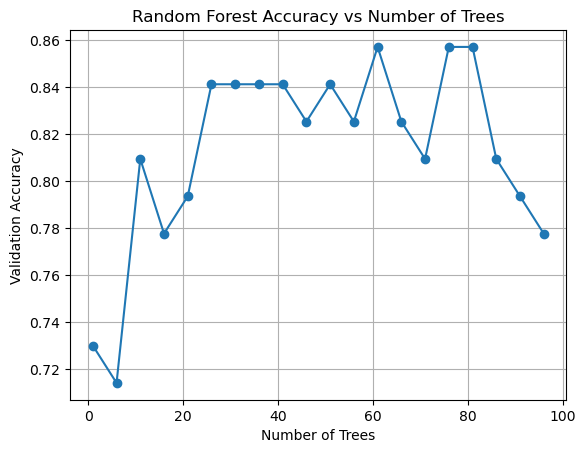

In [30]:
## YOUR CODE HERE
n_trees_list = list(range(1, 101, 5))
accuracies = []

for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    y_val_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    
    accuracies.append(acc)
    print(f"Trees: {n}, Accuracy: {acc:.4f}")

plt.figure()
plt.plot(n_trees_list, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f3d2e979-42f4-4fa4-a66a-116a1c2662d5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>